# Trabajo final: análisis y clasificación de acciones de Microsoft
## Segunda versión: comparación entre datos originales e indicadores derivados

**Problema:** una empresa de análisis financiero necesita un procedimiento reproducible para preparar archivos de mercado, interpretar datos y evaluar si un modelo aporta información útil.

**Pregunta predictiva:** usando únicamente información conocida al finalizar una sesión, ¿el cierre de la siguiente sesión de Microsoft será mayor que el cierre actual?

**Experimento:** se comparan una referencia sencilla, un Random Forest con cinco columnas originales, un Random Forest con cinco indicadores derivados y una red pequeña de PyTorch con los mismos indicadores derivados.

**Motivo de la segunda versión:** los precios absolutos cambian mucho entre décadas. Los indicadores porcentuales describen movimientos relativos y permiten comparar mejor épocas distintas.

**Alcance:** el resultado es una señal experimental de subida o no subida; no calcula el precio exacto, no garantiza rentabilidad y no ejecuta operaciones de inversión.

**Bloque NLP:** procesa secciones reales del reporte anual 2021 de Microsoft con NLTK y SciPy. Se mantiene separado del predictor porque un único reporte no proporciona información diaria para todas las sesiones.


## Antes de ejecutar
1. Coloca este notebook junto a `MSFT.csv`. También admite la estructura `notebooks/` y `data/` del proyecto anterior.
2. Selecciona el kernel de tu entorno virtual en VS Code.
3. Instala las librerías en ese entorno si faltan:

```bash
python -m pip install numpy pandas matplotlib seaborn scikit-learn ipykernel
python -m pip install nltk scipy beautifulsoup4
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
```

La red es pequeña y trabaja en CPU: no necesita una tarjeta gráfica. No se instalan paquetes automáticamente desde las celdas. Si tu versión de Python no tiene una distribución compatible de PyTorch, consulta el selector oficial: https://pytorch.org/get-started/locally/

4. Reinicia el kernel y ejecuta todas las celdas en orden. Las cifras y conclusiones se generan a partir de esa ejecución.

**Fuente del CSV:** https://www.kaggle.com/datasets/varpit94/microsoft-stock-data

**Material:** Sesión 01 (Pandas, NumPy, matrices y preparación; pp. 55, 60, 69, 74 y 84) y Sesión 02 (X/y, clasificación, partición, Scikit-learn, evaluación, redes, tensores y entrenamiento; pp. 23–39 y 41–58).

**Para el bloque NLP:** se consulta el reporte oficial por internet. También puedes guardar su HTML como `Microsoft_AR2021.html` junto al notebook; en ese caso se lee el archivo local. No se necesitan descargas de `punkt`, `stopwords` o `wordnet`: usamos un tokenizador de NLTK que funciona sin esos recursos. El idioma del reporte es inglés y los comentarios están en español.


## 1. Herramientas
Pandas organiza las tablas; NumPy opera sobre vectores y matrices; Matplotlib y Seaborn presentan resultados. Scikit-learn entrenará y evaluará el clasificador.


In [27]:
# Importación de Path para manejar rutas de archivos y directorios de manera más sencilla y segura
from pathlib import Path

# Importación de librerías de análisis de datos y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Configuración de estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Se imprime un mensaje indicando que las librerías se han cargado correctamente, junto con sus versiones
print("Librerias cargadas correctamente")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)


Librerias cargadas correctamente
Pandas: 3.0.5
NumPy: 2.5.2
Scikit-learn: 1.9.0


## 2. Carga y significado del dataset
Cada fila corresponde a una sesión bursátil de Microsoft. Los datos son precios históricos de la acción, no ventas de productos ni ganancias de Microsoft. Las series históricas pueden estar ajustadas por el proveedor; no deben interpretarse automáticamente como cotizaciones nominales originales de décadas pasadas.

| Columna original | Nombre utilizado | Significado |
|---|---|---|
| Date | Fecha | Sesión de negociación |
| Open | Apertura | Precio de apertura registrado |
| High | Maximo | Máximo de la sesión |
| Low | Minimo | Mínimo de la sesión |
| Close | Cierre | Precio de cierre registrado |
| Adj Close | Cierre_Ajustado | Cierre con ajustes del proveedor; se conserva fuera del modelo inicial |
| Volume | Volumen | Volumen de acciones negociadas reportado por la fuente |

**Utilidad:** conocer qué representa cada observación antes de efectuar cálculos.


In [28]:
# Busca el CSV junto al notebook o en las carpetas data del proyecto
candidatas = [carpeta / nombre
              for carpeta in [Path("."), Path("data"), Path("../data")]
              for nombre in ["MSFT.csv"]]

# Elige la primera ruta existente; si no encuentra el CSV, devuelve None
ruta_archivo = next((ruta for ruta in candidatas if ruta.is_file()), None)

# Detiene la ejecución si esta comprobación detecta un problema
if ruta_archivo is None:
    raise FileNotFoundError("Coloca MSFT.csv junto al notebook o en data/.")

# Lee el archivo y conserva esta tabla como referencia original
df_original = pd.read_csv(ruta_archivo)

print("Archivo:", ruta_archivo.name)
print("Dimensiones:", df_original.shape)

# Muestra las 5 primeras filas del DataFrame original sin el índice
print(df_original.head().to_string(index=False))

# Muestra información detallada sobre el DataFrame oiginal
df_original.info()


Archivo: MSFT.csv
Dimensiones: (9083, 7)
      Date     Open     High      Low    Close  Adj Close     Volume
1986-03-13 0.088542 0.101563 0.088542 0.097222   0.061434 1031788800
1986-03-14 0.097222 0.102431 0.097222 0.100694   0.063628  308160000
1986-03-17 0.100694 0.103299 0.100694 0.102431   0.064725  133171200
1986-03-18 0.102431 0.103299 0.098958 0.099826   0.063079   67766400
1986-03-19 0.099826 0.100694 0.097222 0.098090   0.061982   47894400
<class 'pandas.DataFrame'>
RangeIndex: 9083 entries, 0 to 9082
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9083 non-null   str    
 1   Open       9083 non-null   float64
 2   High       9083 non-null   float64
 3   Low        9083 non-null   float64
 4   Close      9083 non-null   float64
 5   Adj Close  9083 non-null   float64
 6   Volume     9083 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 496.9 KB


## 3. Comprobación y preparación
**Utilidad:** detectar problemas que podrían alterar el análisis. Que no existan nulos o duplicados es un resultado válido; no se fabrican errores para justificar la limpieza.

Se revisan columnas esperadas, fechas, números, vacíos, duplicados y coherencia de precios. No se aplica el recorte de 1982 del S&P 500. Si aparecen problemas de precios o datos faltantes, se detiene el proceso para investigarlos: eliminarlos sin revisar podría unir sesiones no consecutivas.


In [3]:
# Relaciona los nombres originales con sus traducciones al español.
nombres = {
    "Date": "Fecha",
    "Open": "Apertura",
    "High": "Maximo",
    "Low": "Minimo",
    "Close": "Cierre",
    "Adj Close": "Cierre_Ajustado",
    "Volume": "Volumen",
}

# Comprueba que el CSV incluya todas las columnas necesarias.
faltantes = set(nombres) - set(df_original.columns)

# Detiene la ejecución si esta comprobación detecta un problema.
if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

# Prepara una copia de los datos para trabajar sin modificar el CSV.
df = df_original.rename(columns=nombres).copy()

print("Nulos originales por columna:")
print(df.isna().sum())

# Cuenta los registros repetidos antes de eliminarlos.
duplicados = int(df.duplicated().sum())

# Elimina solamente filas completamente repetidas.
df = df.drop_duplicates().copy()

# Convierte el texto a fechas; los valores que no se puedan convertir quedan como nulos.
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# Identifica las columnas que deben contener números.
numericas = ["Apertura", "Maximo", "Minimo", "Cierre", "Cierre_Ajustado", "Volumen"]

# Convierte cada columna numérica y marca como nulos los textos inválidos.
for columna in numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

# Detiene la ejecución si esta comprobación detecta un problema.
if df[["Fecha"] + numericas].isna().any().any():
    raise ValueError("Hay fechas o números ausentes/inválidos. Revisarlos antes de continuar.")

# Detiene la ejecución si esta comprobación detecta un problema.
if not np.isfinite(df[numericas].to_numpy()).all():
    raise ValueError("Hay valores numéricos infinitos.")

# Detiene la ejecución si esta comprobación detecta un problema.
if df["Fecha"].duplicated().any():
    raise ValueError("Hay fechas repetidas con registros distintos; revisar la fuente.")

# Ordena las sesiones de la más antigua a la más reciente.
df = df.sort_values("Fecha").reset_index(drop=True)

# Selecciona los precios que deben ser mayores que cero.
precios = ["Apertura", "Maximo", "Minimo", "Cierre", "Cierre_Ajustado"]

print("Precios no positivos:")
print((df[precios] <= 0).sum())

# Marca filas con precios imposibles o volumen negativo.
# El máximo debe ser al menos igual a apertura y cierre; el mínimo no debe superarlos.
incoherentes = ((df[precios] <= 0).any(axis=1) | (df["Volumen"] < 0)
               | (df["Maximo"] < df[["Apertura", "Cierre", "Minimo"]].max(axis=1))
               | (df["Minimo"] > df[["Apertura", "Cierre", "Maximo"]].min(axis=1)))

# Detiene la ejecución si esta comprobación detecta un problema.
if incoherentes.any():
    raise ValueError("Se detectaron precios o volúmenes incoherentes. Revisar esos registros.")

print("Duplicados completos eliminados:", duplicados)
print("Registros preparados:", len(df))
print("Periodo:", df["Fecha"].min().date(), "a", df["Fecha"].max().date())


Nulos originales por columna:
Fecha              0
Apertura           0
Maximo             0
Minimo             0
Cierre             0
Cierre_Ajustado    0
Volumen            0
dtype: int64
Precios no positivos:
Apertura           0
Maximo             0
Minimo             0
Cierre             0
Cierre_Ajustado    0
dtype: int64
Duplicados completos eliminados: 0
Registros preparados: 9083
Periodo: 1986-03-13 a 2022-03-24


## 4. Estadística y NumPy
**Utilidad:** resumir miles de sesiones y representar numéricamente la información. La media del cierre describe el período completo, pero no predice por sí sola el cierre siguiente.

Primero conservamos una matriz con las cinco columnas originales. Más adelante construiremos otra matriz con cinco indicadores derivados de esos mismos datos.


In [4]:
# Columnas originales que forman la primera versión del modelo.
variables_originales = ["Apertura", "Maximo", "Minimo", "Cierre", "Volumen"]

print(df[variables_originales].describe().T.round(3).to_string())

# Una columna forma un vector y varias columnas forman una matriz de NumPy.
vector_cierres = df["Cierre"].to_numpy()
matriz_original = df[variables_originales].to_numpy()

print("Forma del vector de cierres:", vector_cierres.shape)
print("Forma de la matriz original:", matriz_original.shape)
print("Cierre promedio:", round(np.mean(vector_cierres), 3))
print("Cierre mínimo:", round(np.min(vector_cierres), 3))
print("Cierre máximo:", round(np.max(vector_cierres), 3))


           count          mean           std          min           25%          50%           75%           max
Apertura  9083.0  4.132500e+01  5.969700e+01        0.089  4.051000e+00        26.82  4.003500e+01  3.446200e+02
Maximo    9083.0  4.176100e+01  6.027200e+01        0.092  4.102000e+00        27.10  4.044400e+01  3.496700e+02
Minimo    9083.0  4.087800e+01  5.908200e+01        0.089  4.027000e+00        26.52  3.950000e+01  3.422000e+02
Cierre    9083.0  4.133600e+01  5.971500e+01        0.090  4.075000e+00        26.84  3.993800e+01  3.431100e+02
Volumen   9083.0  5.875055e+07  3.845200e+07  2304000.000  3.461230e+07  52032000.00  7.265400e+07  1.031789e+09
Forma del vector de cierres: (9083,)
Forma de la matriz original: (9083, 5)
Cierre promedio: 41.336
Cierre mínimo: 0.09
Cierre máximo: 343.11


## 5. Crear indicadores para la segunda versión
Esta etapa se llama **ingeniería de características**: no inventa información, sino que transforma las columnas originales en medidas más comparables.

| Indicador | Pregunta que responde |
|---|---|
| Retorno_Diario | ¿Cuánto cambió el cierre respecto al día anterior? |
| Rango_Diario | ¿Qué tan amplio fue el movimiento entre mínimo y máximo? |
| Cambio_Intradiario | ¿Cómo terminó la sesión respecto a su apertura? |
| Distancia_MM5 | ¿El cierre está arriba o abajo de su promedio de cinco sesiones? |
| Cambio_Volumen | ¿Cuánto cambió la actividad respecto a la sesión anterior? |

Las proporciones se guardan en formato decimal: `0.02` representa 2 %. Solo utilizan la sesión actual y sesiones anteriores. La media móvil de cinco días es auxiliar; el modelo recibe la distancia porcentual respecto a ella.


In [5]:
# 1. Variación porcentual del cierre respecto a la sesión anterior.
df["Retorno_Diario"] = df["Cierre"].pct_change(fill_method=None)

# 2. Amplitud porcentual entre máximo y mínimo durante la sesión.
df["Rango_Diario"] = (
    (df["Maximo"] - df["Minimo"]) / df["Apertura"]
)

# 3. Cambio porcentual desde la apertura hasta el cierre.
df["Cambio_Intradiario"] = (
    (df["Cierre"] - df["Apertura"]) / df["Apertura"]
)

# 4. Promedio de los últimos cinco cierres, incluyendo el actual.
df["Media_Movil_5"] = df["Cierre"].rolling(window=5).mean()

# Distancia porcentual del cierre respecto a ese promedio reciente.
df["Distancia_MM5"] = df["Cierre"] / df["Media_Movil_5"] - 1

# 5. Variación porcentual del volumen respecto a la sesión anterior.
df["Cambio_Volumen"] = df["Volumen"].pct_change(fill_method=None)

variables_derivadas = [
    "Retorno_Diario",
    "Rango_Diario",
    "Cambio_Intradiario",
    "Distancia_MM5",
    "Cambio_Volumen",
]

# Si una división excepcional produjera infinito, se marca para excluirla.
df[variables_derivadas] = df[variables_derivadas].replace(
    [np.inf, -np.inf], np.nan
)

print(df[variables_derivadas].describe().T.round(5).to_string())

# Segunda matriz numérica: mismas sesiones disponibles, cinco indicadores.
matriz_indicadores = df[variables_derivadas].dropna().to_numpy()
print("Forma de la matriz de indicadores:", matriz_indicadores.shape)


                     count     mean      std      min      25%      50%      75%       max
Retorno_Diario      9082.0  0.00111  0.02133 -0.30116 -0.00921  0.00034  0.01124   0.19565
Rango_Diario        9083.0  0.02524  0.01607  0.00375  0.01446  0.02132  0.03130   0.30081
Cambio_Intradiario  9083.0  0.00068  0.01831 -0.26423 -0.00861  0.00000  0.00987   0.15758
Distancia_MM5       9079.0  0.00185  0.02268 -0.30385 -0.00972  0.00159  0.01330   0.16562
Cambio_Volumen      9082.0  0.09734  0.62874 -0.93839 -0.20511 -0.01268  0.24464  14.59415
Forma de la matriz de indicadores: (9079, 5)


## 6. Visualización para el analista
La línea muestra la evolución histórica; el histograma permite observar la distribución de los cambios diarios; y la última figura compara el cierre con su promedio móvil reciente.

Estos gráficos describen lo sucedido. No demuestran por sí solos que sea posible anticipar la siguiente sesión.


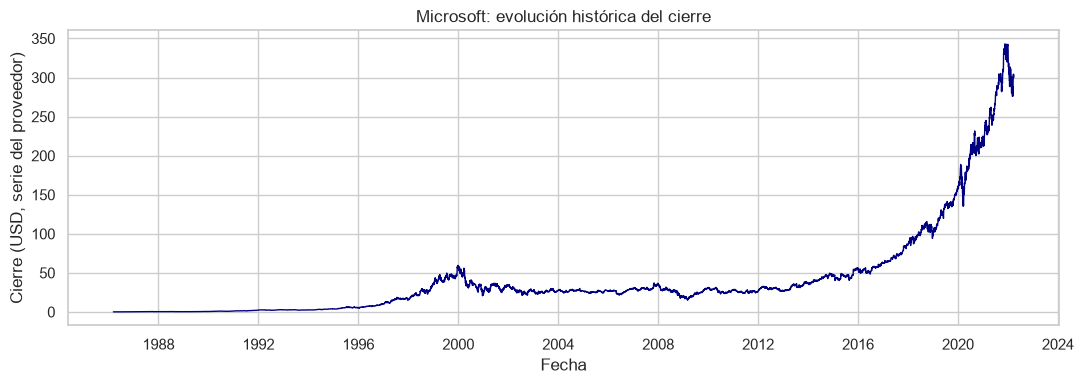

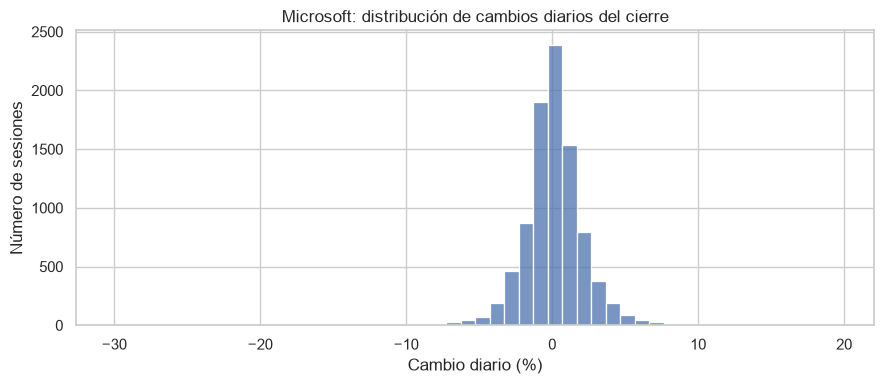

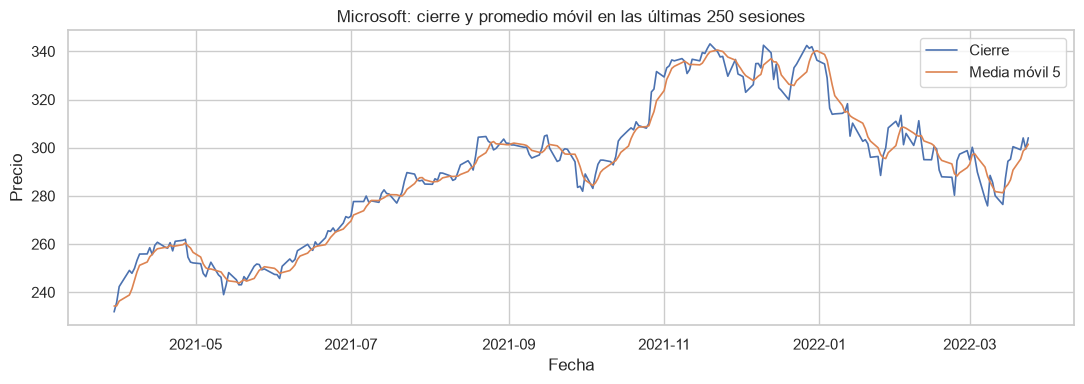

In [6]:
# Evolución histórica del cierre.
plt.figure(figsize=(11, 4))
plt.plot(df["Fecha"], df["Cierre"], color="navy", linewidth=1)
plt.title("Microsoft: evolución histórica del cierre")
plt.xlabel("Fecha")
plt.ylabel("Cierre (USD, serie del proveedor)")
plt.tight_layout()
plt.show()

# Distribución de los cambios porcentuales diarios.
plt.figure(figsize=(9, 4))
sns.histplot(df["Retorno_Diario"].dropna() * 100, bins=50)
plt.title("Microsoft: distribución de cambios diarios del cierre")
plt.xlabel("Cambio diario (%)")
plt.ylabel("Número de sesiones")
plt.tight_layout()
plt.show()

# Vista reciente del cierre y su promedio de cinco sesiones.
ultimas = df.tail(250)
plt.figure(figsize=(11, 4))
plt.plot(ultimas["Fecha"], ultimas["Cierre"], label="Cierre", linewidth=1.2)
plt.plot(ultimas["Fecha"], ultimas["Media_Movil_5"], label="Media móvil 5", linewidth=1.2)
plt.title("Microsoft: cierre y promedio móvil en las últimas 250 sesiones")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Definir X e y
Se conservan dos grupos de entradas para una comparación justa:

- **X original:** apertura, máximo, mínimo, cierre y volumen.
- **X derivada:** retorno, rango, cambio intradiario, distancia a la media móvil y cambio del volumen.

La respuesta **y** es la misma para ambos: `1` cuando el cierre siguiente es mayor y `0` cuando es menor o igual. `Cierre_Siguiente` solo construye la respuesta histórica y se retira antes del entrenamiento.

Las primeras filas incompletas se eliminan porque aún no tienen cinco sesiones para formar la media móvil. La última se elimina porque todavía no posee una respuesta futura conocida.


In [7]:
# Conserva fecha, columnas originales e indicadores en una tabla supervisada.
columnas_necesarias = ["Fecha"] + variables_originales + variables_derivadas
df_ml = df[columnas_necesarias].copy()

# Lleva la fecha y el cierre siguientes hacia la fila actual.
df_ml["Fecha_Objetivo"] = df["Fecha"].shift(-1)
df_ml["Cierre_Siguiente"] = df["Cierre"].shift(-1)

# Excluye filas que todavía no permiten calcular los indicadores y la última sesión.
df_ml = df_ml.dropna(
    subset=variables_derivadas + ["Fecha_Objetivo", "Cierre_Siguiente"]
).copy()

# Respuesta: 1 = sube; 0 = baja o se mantiene.
df_ml["Tendencia_Siguiente_Dia"] = (
    df_ml["Cierre_Siguiente"] > df_ml["Cierre"]
).astype(int)

print(df_ml[[
    "Fecha", "Cierre", "Fecha_Objetivo", "Cierre_Siguiente",
    "Tendencia_Siguiente_Dia"
]].head(8).to_string(index=False))

# Se elimina la respuesta futura para impedir fuga de información.
df_ml = df_ml.drop(columns="Cierre_Siguiente").reset_index(drop=True)

X_original = df_ml[variables_originales]
X_derivada = df_ml[variables_derivadas]
y = df_ml["Tendencia_Siguiente_Dia"]

print("X original:", X_original.shape)
print("X derivada:", X_derivada.shape)
print("y:", y.shape)

distribucion = y.value_counts().reindex([0, 1], fill_value=0)
print(pd.DataFrame({
    "Cantidad": distribucion,
    "Porcentaje": distribucion / len(y) * 100,
}).round(2))


     Fecha   Cierre Fecha_Objetivo  Cierre_Siguiente  Tendencia_Siguiente_Dia
1986-03-19 0.098090     1986-03-20          0.095486                        0
1986-03-20 0.095486     1986-03-21          0.092882                        0
1986-03-21 0.092882     1986-03-24          0.090278                        0
1986-03-24 0.090278     1986-03-25          0.092014                        1
1986-03-25 0.092014     1986-03-26          0.094618                        1
1986-03-26 0.094618     1986-03-27          0.096354                        1
1986-03-27 0.096354     1986-03-31          0.095486                        0
1986-03-31 0.095486     1986-04-01          0.094618                        0
X original: (9078, 5)
X derivada: (9078, 5)
y: (9078,)
                         Cantidad  Porcentaje
Tendencia_Siguiente_Dia                      
0                            4500       49.57
1                            4578       50.43


## 8. Entrenamiento, validación y prueba en orden cronológico

| Conjunto | Proporción aproximada | Función |
|---|---|---|
| Entrenamiento | Primer 60 % | Aprender reglas o pesos |
| Validación | Siguiente 20 % | Observar el comportamiento y seleccionar la época de la red |
| Prueba | Último 20 % | Comparar los modelos ya fijados |

No mezclamos las filas aleatoriamente porque los datos poseen orden temporal. También dejamos una fila fuera en cada frontera para impedir que la etiqueta de un conjunto consulte el cierre perteneciente al conjunto siguiente.

Las versiones original y derivada utilizan exactamente las mismas fechas. Por eso cualquier diferencia procede de la representación de las entradas, no de una prueba más fácil.


In [8]:
fin_entrenamiento = int(len(df_ml) * 0.60)
inicio_prueba = int(len(df_ml) * 0.80)

# Excluye una fila en cada frontera temporal.
datos_train = df_ml.iloc[:fin_entrenamiento - 1].copy()
datos_val = df_ml.iloc[fin_entrenamiento:inicio_prueba - 1].copy()
datos_test = df_ml.iloc[inicio_prueba:].copy()

# Entradas originales.
X_train_original = datos_train[variables_originales]
X_val_original = datos_val[variables_originales]
X_test_original = datos_test[variables_originales]

# Entradas de la segunda versión.
X_train = datos_train[variables_derivadas]
X_val = datos_val[variables_derivadas]
X_test = datos_test[variables_derivadas]

y_train = datos_train["Tendencia_Siguiente_Dia"]
y_val = datos_val["Tendencia_Siguiente_Dia"]
y_test = datos_test["Tendencia_Siguiente_Dia"]

assert datos_train["Fecha_Objetivo"].max() < datos_val["Fecha"].min()
assert datos_val["Fecha_Objetivo"].max() < datos_test["Fecha"].min()

particiones = []
for nombre, datos in [
    ("Entrenamiento", datos_train),
    ("Validación", datos_val),
    ("Prueba", datos_test),
]:
    particiones.append({
        "Conjunto": nombre,
        "Sesiones": len(datos),
        "Desde": datos["Fecha"].min().date(),
        "Hasta": datos["Fecha"].max().date(),
        "Subidas (%)": datos["Tendencia_Siguiente_Dia"].mean() * 100,
    })

print(pd.DataFrame(particiones).round(2).to_string(index=False))
print("Sesiones excluidas entre conjuntos: 2")


     Conjunto  Sesiones      Desde      Hasta  Subidas (%)
Entrenamiento      5445 1986-03-19 2007-10-17        49.59
   Validación      1815 2007-10-19 2015-01-05        49.64
       Prueba      1816 2015-01-07 2022-03-23        53.74
Sesiones excluidas entre conjuntos: 2


## 9. Comparación con Random Forest
Entrenamos dos bosques con la misma configuración y las mismas filas:

1. **Random Forest original:** recibe los cinco valores absolutos del CSV.
2. **Random Forest V2:** recibe los cinco indicadores porcentuales y recientes.

El objetivo no es obligar al segundo a ganar, sino comprobar con evidencia si la transformación ayuda. Los parámetros se mantienen iguales para no atribuir a las nuevas variables una mejora producida por otro ajuste.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

parametros_rf = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_leaf": 10,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

modelo_rf_original = RandomForestClassifier(**parametros_rf)
modelo_rf_v2 = RandomForestClassifier(**parametros_rf)

# Entrena ambos modelos con sus respectivas entradas y la misma respuesta.
modelo_rf_original.fit(X_train_original, y_train)
modelo_rf_v2.fit(X_train, y_train)

print("Random Forest original entrenado.")
print("Random Forest V2 entrenado.")


Random Forest original entrenado.
Random Forest V2 entrenado.


## 10. Preparar los indicadores para PyTorch
La red utiliza los cinco indicadores de la segunda versión. `StandardScaler` aprende la media y la desviación únicamente del entrenamiento; después aplica esa misma transformación a validación y prueba.

Estandarizar facilita el trabajo numérico de la red, pero no añade información nueva ni garantiza una mejora. El tensor X mantiene la forma `(sesiones, 5)`.


In [10]:
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
torch.set_num_threads(2)
print("Versión de PyTorch:", torch.__version__)

escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)
X_val_escalado = escalador.transform(X_val)
X_test_escalado = escalador.transform(X_test)

X_train_tensor = torch.tensor(X_train_escalado, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_escalado, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_escalado, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.to_numpy().reshape(-1, 1), dtype=torch.float32
)
y_val_tensor = torch.tensor(
    y_val.to_numpy().reshape(-1, 1), dtype=torch.float32
)

print("X de entrenamiento:", tuple(X_train_tensor.shape))
print("y de entrenamiento:", tuple(y_train_tensor.shape))
print(pd.DataFrame({
    "Variable": variables_derivadas,
    "Media_train": escalador.mean_,
    "Desviacion_train": escalador.scale_,
}).round(5).to_string(index=False))


Versión de PyTorch: 2.14.0+cpu
X de entrenamiento: (5445, 5)
y de entrenamiento: (5445, 1)
          Variable  Media_train  Desviacion_train
    Retorno_Diario      0.00133           0.02327
      Rango_Diario      0.02863           0.01701
Cambio_Intradiario      0.00086           0.02066
     Distancia_MM5      0.00221           0.02537
    Cambio_Volumen      0.12455           0.74043


## 11. Crear una red neuronal pequeña
La arquitectura continúa siendo sencilla: **5 entradas → 8 neuronas ocultas → 1 salida**. La diferencia es que ahora sus entradas representan movimientos relativos.

| Componente | Función |
|---|---|
| `Linear(5, 8)` | Combina los cinco indicadores mediante pesos y sesgos |
| `ReLU()` | Permite aprender relaciones no lineales |
| `Linear(8, 1)` | Produce el puntaje de clasificación |
| `BCEWithLogitsLoss()` | Mide el error binario |
| `Adam` | Actualiza los pesos usando los gradientes |

Sigue siendo una red densa de una fila por ejemplo; no es una LSTM ni procesa una ventana completa como una sola entrada.


In [11]:
# Crea las capas en el orden en que se procesará la información.
modelo_torch = nn.Sequential(
    nn.Linear(5, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)

# Define cómo medir el error y cómo actualizar los pesos.
funcion_perdida = nn.BCEWithLogitsLoss()
optimizador = torch.optim.Adam(
    modelo_torch.parameters(),
    lr=0.001,
)

print(modelo_torch)
print("Parámetros entrenables:", sum(p.numel() for p in modelo_torch.parameters()))


Sequential(
  (0): Linear(in_features=5, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
Parámetros entrenables: 57


## 12. Entrenar y observar la validación
Esta celda aplica el ciclo de la **página 58 de la sesión 02**:

1. **Forward:** calcula la salida.
2. **Loss:** mide el error frente a la respuesta histórica.
3. **Backward:** calcula cómo cambia el error respecto a cada peso.
4. **Step:** actualiza los pesos.

Una época realiza aquí una actualización usando todo el pequeño conjunto de entrenamiento. Después medimos el error de validación **sin actualizar pesos**.

Guardamos los pesos de la época con menor pérdida de validación y detenemos el proceso si pasan 30 épocas sin mejorar. El máximo es 300 épocas. Este criterio se fija antes de ver la prueba; no se modifica hasta obtener una cifra deseada.

La pérdida es una medida para entrenar: **no es un porcentaje de errores** ni una pérdida monetaria.


In [12]:
from copy import deepcopy

# Límites de entrenamiento y memoria de la mejor época.
max_epocas = 300
paciencia = 30
sin_mejora = 0
mejor_perdida = float("inf")
mejor_epoca = 0
mejores_pesos = None
historial = []

for epoca in range(1, max_epocas + 1):
    modelo_torch.train()

    # Borra gradientes anteriores antes de calcular los nuevos.
    optimizador.zero_grad()

    # 1. Forward: calcula un logit por sesión.
    logits = modelo_torch(X_train_tensor)

    # 2. Loss: compara las salidas con las respuestas conocidas.
    perdida = funcion_perdida(logits, y_train_tensor)

    # 3. Backward: Autograd calcula los gradientes.
    perdida.backward()

    # 4. Step: Adam actualiza los pesos de la red.
    optimizador.step()

    # Evalúa ambos conjuntos después de la actualización, sin gradientes.
    modelo_torch.eval()
    with torch.no_grad():
        perdida_train = funcion_perdida(
            modelo_torch(X_train_tensor), y_train_tensor
        ).item()
        perdida_val = funcion_perdida(
            modelo_torch(X_val_tensor), y_val_tensor
        ).item()

    historial.append({
        "Epoca": epoca,
        "Entrenamiento": perdida_train,
        "Validacion": perdida_val,
    })

    # Conserva únicamente la época elegida mediante validación.
    if perdida_val < mejor_perdida:
        mejor_perdida = perdida_val
        mejor_epoca = epoca
        mejores_pesos = deepcopy(modelo_torch.state_dict())
        sin_mejora = 0
    else:
        sin_mejora += 1

    if epoca == 1 or epoca % 50 == 0:
        print(f"Época {epoca}: train={perdida_train:.4f}, val={perdida_val:.4f}")

    if sin_mejora >= paciencia:
        print("Detención por falta de mejora en validación.")
        break

# Recupera los mejores pesos; no utiliza la última época por defecto.
modelo_torch.load_state_dict(mejores_pesos)
modelo_torch.eval()

historial = pd.DataFrame(historial)
print("Épocas realizadas:", len(historial))
print("Época seleccionada:", mejor_epoca)
print("Mejor pérdida de validación:", round(mejor_perdida, 4))


Época 1: train=0.6946, val=0.6916
Detención por falta de mejora en validación.
Épocas realizadas: 31
Época seleccionada: 1
Mejor pérdida de validación: 0.6916


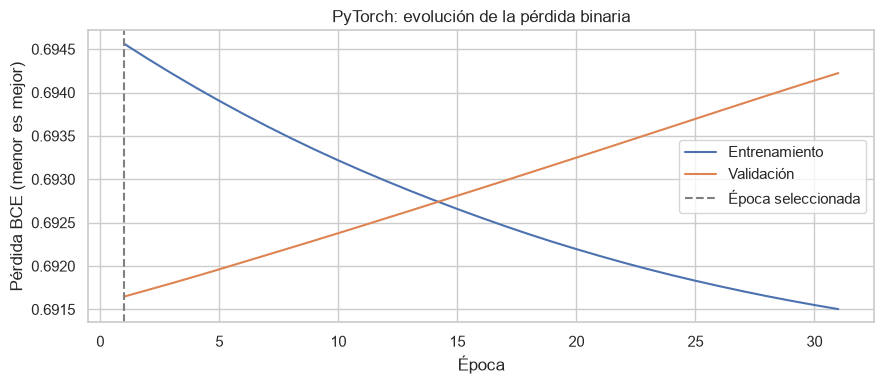

In [13]:
# Compara cómo evolucionó el error en entrenamiento y validación.
plt.figure(figsize=(9, 4))
plt.plot(historial["Epoca"], historial["Entrenamiento"], label="Entrenamiento")
plt.plot(historial["Epoca"], historial["Validacion"], label="Validación")
plt.axvline(mejor_epoca, color="gray", linestyle="--", label="Época seleccionada")
plt.title("PyTorch: evolución de la pérdida binaria")
plt.xlabel("Época")
plt.ylabel("Pérdida BCE (menor es mejor)")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Evaluar los modelos fijados
Se comparan cuatro alternativas: referencia mayoritaria, bosque original, bosque V2 y red V2. La clase positiva es **sube (1)**.

| Métrica | Significado sencillo |
|---|---|
| Accuracy | Porcentaje total de aciertos |
| Balanced Accuracy | Promedio de acierto sobre ambas clases |
| Precision | De las subidas anunciadas, cuántas ocurrieron |
| Recall | De las subidas reales, cuántas fueron detectadas |
| F1 | Equilibrio entre Precision y Recall |

La referencia responde siempre con la clase más frecuente del entrenamiento. Superarla es una primera condición; todavía no demuestra rentabilidad.


In [14]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

def metricas(real, predicha):
    return {
        "Accuracy": accuracy_score(real, predicha),
        "Balanced Accuracy": balanced_accuracy_score(real, predicha),
        "Precision": precision_score(real, predicha, zero_division=0),
        "Recall": recall_score(real, predicha, zero_division=0),
        "F1": f1_score(real, predicha, zero_division=0),
    }

def predecir_red(entradas):
    modelo_torch.eval()
    with torch.no_grad():
        probabilidades = torch.sigmoid(modelo_torch(entradas)).numpy().ravel()
    return (probabilidades >= 0.5).astype(int)

clase_mayoritaria = int(y_train.mode().iloc[0])
print("Clase fija de referencia:", clase_mayoritaria)

predicciones_val = {
    "Referencia": np.full(len(y_val), clase_mayoritaria),
    "RF original": modelo_rf_original.predict(X_val_original),
    "RF V2": modelo_rf_v2.predict(X_val),
    "PyTorch V2": predecir_red(X_val_tensor),
}

resultados_val = pd.DataFrame({
    nombre: metricas(y_val, predicha)
    for nombre, predicha in predicciones_val.items()
}).T

print("VALIDACIÓN: métricas en porcentaje")
print((resultados_val * 100).round(2).to_string())


Clase fija de referencia: 0
VALIDACIÓN: métricas en porcentaje
             Accuracy  Balanced Accuracy  Precision  Recall     F1
Referencia      50.36              50.00       0.00    0.00   0.00
RF original     51.57              51.52      51.41   44.62  47.77
RF V2           50.14              50.04      49.69   35.96  41.73
PyTorch V2      51.18              51.19      50.81   52.39  51.58


In [15]:
# Evalúa el período final sin volver a ajustar los modelos.
predicciones_test = {
    "Referencia": np.full(len(y_test), clase_mayoritaria),
    "RF original": modelo_rf_original.predict(X_test_original),
    "RF V2": modelo_rf_v2.predict(X_test),
    "PyTorch V2": predecir_red(X_test_tensor),
}

resultados_test = pd.DataFrame({
    nombre: metricas(y_test, predicha)
    for nombre, predicha in predicciones_test.items()
}).T

print("PRUEBA: métricas en porcentaje")
print((resultados_test * 100).round(2).to_string())

# Accuracy de entrenamiento y períodos posteriores.
predicciones_train = {
    "RF original": modelo_rf_original.predict(X_train_original),
    "RF V2": modelo_rf_v2.predict(X_train),
    "PyTorch V2": predecir_red(X_train_tensor),
}

resumen_generalizacion = pd.DataFrame({
    nombre: {
        "Train": accuracy_score(y_train, predicciones_train[nombre]),
        "Validacion": resultados_val.loc[nombre, "Accuracy"],
        "Prueba": resultados_test.loc[nombre, "Accuracy"],
    }
    for nombre in predicciones_train
}).T

print("EXACTITUD POR PERÍODO (%)")
print((resumen_generalizacion * 100).round(2).to_string())


PRUEBA: métricas en porcentaje
             Accuracy  Balanced Accuracy  Precision  Recall     F1
Referencia      46.26              50.00       0.00    0.00   0.00
RF original     46.37              49.90      51.92    2.77   5.25
RF V2           51.76              53.18      58.80   34.22  43.26
PyTorch V2      52.20              52.12      55.81   53.18  54.46
EXACTITUD POR PERÍODO (%)
             Train  Validacion  Prueba
RF original  66.69       51.57   46.37
RF V2        71.09       50.14   51.76
PyTorch V2   49.61       51.18   52.20


## 14. Comparar aciertos y errores
El gráfico resume Accuracy y Balanced Accuracy. Las matrices de confusión revelan cuántas veces cada modelo reconoció `No sube` y `Sube`.

Un modelo útil no debería parecer bueno únicamente por repetir una clase. Por eso no observamos solo la exactitud total.


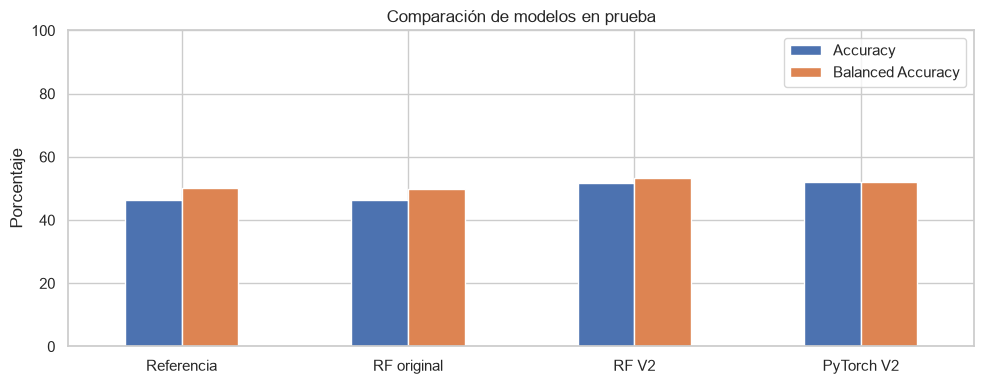

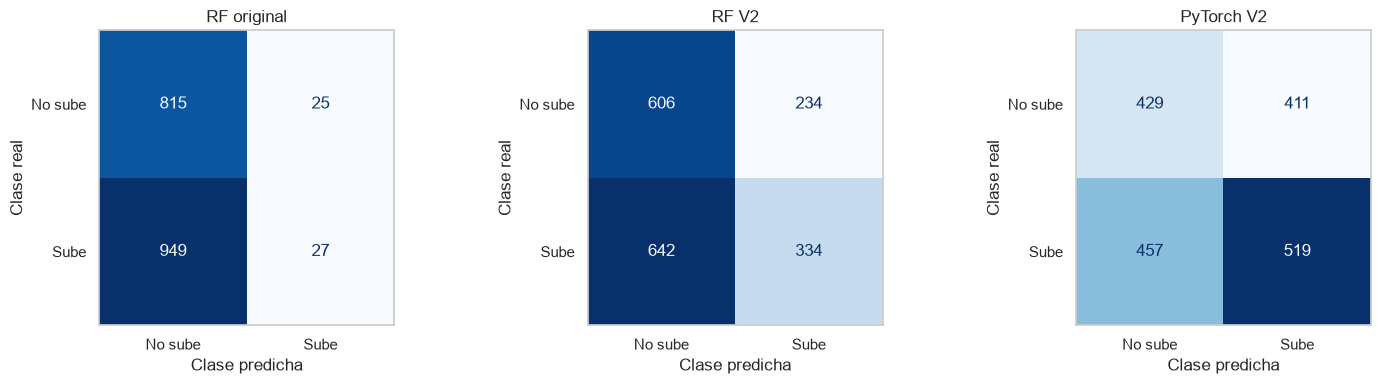

In [16]:
(resultados_test[["Accuracy", "Balanced Accuracy"]] * 100).plot.bar(
    figsize=(10, 4), rot=0
)
plt.title("Comparación de modelos en prueba")
plt.ylabel("Porcentaje")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

for eje, nombre in zip(ejes, ["RF original", "RF V2", "PyTorch V2"]):
    matriz = confusion_matrix(y_test, predicciones_test[nombre], labels=[0, 1])
    ConfusionMatrixDisplay(
        matriz, display_labels=["No sube", "Sube"]
    ).plot(ax=eje, cmap="Blues", colorbar=False)
    eje.set_title(nombre)
    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")
    eje.grid(False)

plt.tight_layout()
plt.show()


Fecha_informacion Sesion_predicha  Real  RF original  RF V2  PyTorch V2
       2015-01-07      2015-01-08     1            0      0           1
       2015-01-08      2015-01-09     0            0      0           0
       2015-01-09      2015-01-12     0            0      0           0
       2015-01-12      2015-01-13     0            0      0           0
       2015-01-13      2015-01-14     0            0      0           1
       2015-01-14      2015-01-15     0            0      0           1
       2015-01-15      2015-01-16     1            1      1           1
       2015-01-16      2015-01-20     1            0      0           0
       2015-01-20      2015-01-21     0            1      0           0
       2015-01-21      2015-01-22     1            1      0           1
       2015-01-22      2015-01-23     1            0      0           0
       2015-01-23      2015-01-26     0            0      1           0


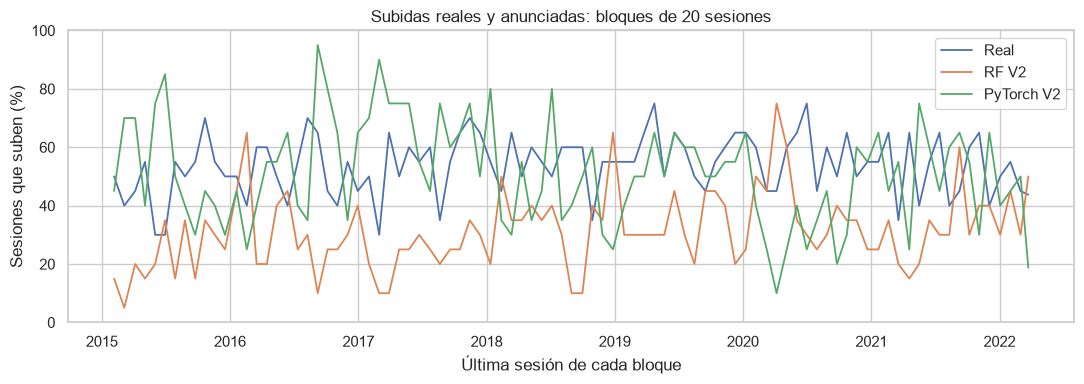

In [17]:
# Relaciona la sesión con información y la sesión que se intentó predecir.
comparacion = pd.DataFrame({
    "Fecha_informacion": datos_test["Fecha"].to_numpy(),
    "Sesion_predicha": datos_test["Fecha_Objetivo"].to_numpy(),
    "Real": y_test.to_numpy(),
    "RF original": predicciones_test["RF original"],
    "RF V2": predicciones_test["RF V2"],
    "PyTorch V2": predicciones_test["PyTorch V2"],
})

print(comparacion.head(12).to_string(index=False))

# Agrupa 20 sesiones consecutivas solo para visualizar proporciones.
bloques = np.arange(len(comparacion)) // 20
tendencias = comparacion.groupby(bloques).agg({
    "Sesion_predicha": "max",
    "Real": "mean",
    "RF original": "mean",
    "RF V2": "mean",
    "PyTorch V2": "mean",
})

plt.figure(figsize=(11, 4))
for columna in ["Real", "RF V2", "PyTorch V2"]:
    plt.plot(
        tendencias["Sesion_predicha"],
        tendencias[columna] * 100,
        label=columna,
        linewidth=1.3,
    )

plt.title("Subidas reales y anunciadas: bloques de 20 sesiones")
plt.xlabel("Última sesión de cada bloque")
plt.ylabel("Sesiones que suben (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


## 15. Interpretar los indicadores del bosque V2
La importancia interna muestra qué indicadores utilizó más el Random Forest V2 para dividir sus árboles. No significa causalidad ni garantiza que una variable funcione por separado.


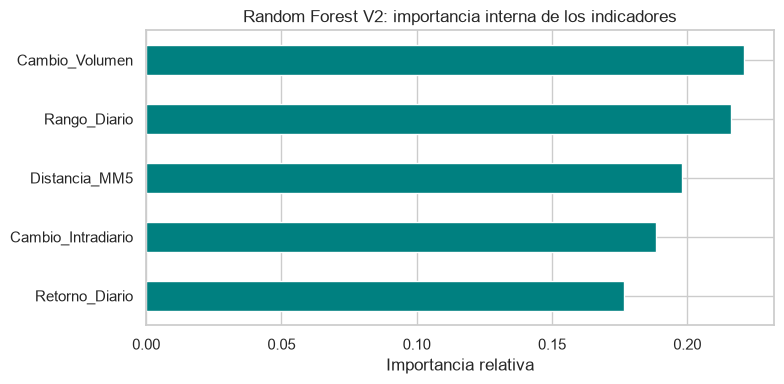

In [18]:
importancias = pd.Series(
    modelo_rf_v2.feature_importances_,
    index=variables_derivadas,
).sort_values()

importancias.plot.barh(color="teal", figsize=(8, 4))
plt.title("Random Forest V2: importancia interna de los indicadores")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


## 16. Conclusiones automáticas
Esta sección responde si la segunda representación mejoró frente a la primera y frente a la referencia. Una mejora en clasificación es evidencia técnica, pero no equivale directamente a beneficio económico.

Para demostrar rentabilidad se necesitaría definir una estrategia, considerar comisiones, dividendos, riesgo y comparar el capital final con otra alternativa.


In [19]:
print(f"Se prepararon {len(df):,} sesiones y {len(df_ml):,} ejemplos comparables.")
print("Los dos bosques recibieron las mismas fechas y la misma respuesta histórica.")
print(f"La red seleccionó la época {mejor_epoca} mediante validación.")

exactitud_referencia = resultados_test.loc["Referencia", "Accuracy"]
aciertos_referencia = int(
    (predicciones_test["Referencia"] == y_test.to_numpy()).sum()
)

for nombre in ["RF original", "RF V2", "PyTorch V2"]:
    fila = resultados_test.loc[nombre]
    aciertos = int((predicciones_test[nombre] == y_test.to_numpy()).sum())
    diferencia = fila["Accuracy"] - exactitud_referencia

    print(f"\n{nombre}")
    print(f"  Accuracy de prueba: {fila['Accuracy']:.2%}")
    print(f"  Balanced Accuracy: {fila['Balanced Accuracy']:.2%}")
    print(f"  Recall de subidas: {fila['Recall']:.2%}")
    print(f"  Diferencia frente a referencia: {diferencia * 100:+.2f} puntos")
    print(f"  Aciertos adicionales: {aciertos - aciertos_referencia:+d}")
    print(f"  Sesiones anunciadas como subida: {np.mean(predicciones_test[nombre]):.2%}")

    if len(np.unique(predicciones_test[nombre])) == 1:
        print("  Atención: predijo una sola clase en toda la prueba.")

diferencia_v2 = (
    resultados_test.loc["RF V2", "Accuracy"]
    - resultados_test.loc["RF original", "Accuracy"]
)
print(
    "\nCambio de RF V2 frente a RF original:",
    f"{diferencia_v2 * 100:+.2f} puntos porcentuales de Accuracy."
)

print("\nLa exactitud no mide rentabilidad ni indica cuánto subiría el precio.")
print("El CSV termina en 2022; no representa una predicción del mercado de 2026.")
print("El bloque NLP posterior permanece separado de estos modelos.")


Se prepararon 9,083 sesiones y 9,078 ejemplos comparables.
Los dos bosques recibieron las mismas fechas y la misma respuesta histórica.
La red seleccionó la época 1 mediante validación.

RF original
  Accuracy de prueba: 46.37%
  Balanced Accuracy: 49.90%
  Recall de subidas: 2.77%
  Diferencia frente a referencia: +0.11 puntos
  Aciertos adicionales: +2
  Sesiones anunciadas como subida: 2.86%

RF V2
  Accuracy de prueba: 51.76%
  Balanced Accuracy: 53.18%
  Recall de subidas: 34.22%
  Diferencia frente a referencia: +5.51 puntos
  Aciertos adicionales: +100
  Sesiones anunciadas como subida: 31.28%

PyTorch V2
  Accuracy de prueba: 52.20%
  Balanced Accuracy: 52.12%
  Recall de subidas: 53.18%
  Diferencia frente a referencia: +5.95 puntos
  Aciertos adicionales: +108
  Sesiones anunciadas como subida: 51.21%

Cambio de RF V2 frente a RF original: +5.40 puntos porcentuales de Accuracy.

La exactitud no mide rentabilidad ni indica cuánto subiría el precio.
El CSV termina en 2022; no r

## 17. NLP: convertir un reporte financiero en información consultable

**Problema del analista:** además de precios en CSV, recibe documentos extensos. Necesita localizar temas y cifras sin revisar manualmente todos los párrafos cada vez.

**Propuesta:** procesar tres secciones del reporte anual 2021 de Microsoft: carta a accionistas, discusión de resultados y riesgo de mercado. No se procesa la totalidad de sus tablas contables.

| Herramienta | Trabajo concreto |
|---|---|
| BeautifulSoup | Extraer párrafos del HTML oficial |
| NLTK | Dividir el texto en palabras y contar sus frecuencias |
| SciPy | Representar párrafos y términos en una matriz dispersa y calcular coincidencia con una consulta |
| Expresiones regulares | Extraer cifras mediante patrones textuales definidos |

**Alcance:** cumple la exploración NLP, la tokenización y una extracción inicial de información. No hace análisis de sentimiento; el enunciado admite **sentimiento o tokenización**. Contar términos financieros no permite concluir que la empresa está bien o mal.

Este bloque es independiente de X e y. El reporte de 2021 no se asigna a sesiones anteriores ni se utiliza para entrenar los clasificadores. Para incorporarlo a una predicción se necesitarían fechas reales de publicación, disponibilidad histórica y varios reportes, no solo su año fiscal.


## 18. Leer el reporte oficial y seleccionar los párrafos

Fuente: https://www.microsoft.com/investor/reports/ar21/

El año fiscal analizado termina el **30 de junio de 2021**; no debe confundirse con la fecha de publicación. Se conserva el enlace de cada sección para verificar los hallazgos.

Se omiten tablas y párrafos de menos de 20 palabras para reducir fragmentos de navegación. Se eliminan repeticiones exactas. Esta selección limita el alcance y puede omitir información corta relevante; no es un resumen completo del reporte.

Si cambia la estructura de la página, el proceso se detiene con un mensaje. Nunca sustituye el documento por un texto inventado.


In [ ]:
# El análisis de texto requiere BeautifulSoup y un HTML local o descargado.
import re
import hashlib
from urllib.request import Request, urlopen
from bs4 import BeautifulSoup

# Usa la fuente oficial o una copia HTML descargada por el usuario.
url_reporte = "https://www.microsoft.com/investor/reports/ar21/"
archivo_reporte = Path("Microsoft_AR2021.html")

if archivo_reporte.is_file():
    html_reporte = archivo_reporte.read_bytes()
    print("Origen: archivo HTML local.")
else:
    solicitud = Request(
        url_reporte,
        headers={"User-Agent": "Mozilla/5.0 (educational financial analysis)"},
    )
    try:
        with urlopen(solicitud, timeout=30) as respuesta:
            html_reporte = respuesta.read()
    except Exception as error:
        raise RuntimeError(
            "No se pudo obtener el reporte. Revisa internet o guarda "
            "el HTML oficial como Microsoft_AR2021.html junto al notebook."
        ) from error
    print("Origen: sitio oficial de Microsoft.")

# Selecciona tres secciones identificadas en el documento.
pagina_reporte = BeautifulSoup(html_reporte, "html.parser")
secciones_nlp = {
    "shareholder-letter": "Carta a accionistas",
    "discussion-analysis": "Discusión de resultados",
    "market-risk": "Riesgo de mercado",
}

registros_texto = []
textos_vistos = set()

for identificador, nombre in secciones_nlp.items():
    seccion = pagina_reporte.find(id=identificador)
    if seccion is None:
        raise ValueError(f"No se encontró la sección {identificador}. Revisar el HTML.")

    for parrafo in seccion.find_all("p"):
        # Las tablas financieras requieren un tratamiento diferente.
        if parrafo.find_parent("table") is not None:
            continue

        texto = re.sub(r"\s+", " ", parrafo.get_text(" ", strip=True)).strip()
        if len(texto.split()) < 20 or texto in textos_vistos:
            continue

        textos_vistos.add(texto)
        registros_texto.append({
            "ID": f"P{len(registros_texto) + 1:03}",
            "Seccion": nombre,
            "Texto": texto,
            "Fuente": f"{url_reporte}#{identificador}",
        })

parrafos_nlp = pd.DataFrame(registros_texto)
if parrafos_nlp.empty:
    raise ValueError("No se extrajeron párrafos. Revisa la estructura del reporte.")

# Una huella permite identificar el corpus exacto de esta ejecución.
texto_corpus = "\n".join(parrafos_nlp["Texto"])
huella_corpus = hashlib.sha256(texto_corpus.encode("utf-8")).hexdigest()

print("Párrafos analizados:", len(parrafos_nlp))
print(parrafos_nlp.groupby("Seccion").size().to_string())
print("SHA-256 del texto seleccionado:", huella_corpus)
print("Fuente:", url_reporte)


Origen: archivo HTML local.
Párrafos analizados: 139
Seccion
Carta a accionistas        58
Discusión de resultados    76
Riesgo de mercado           5
SHA-256 del texto seleccionado: d2b621c4daab8549bca671244a5addeff07d10c37e6270bd3f167cf88df856ca
Fuente: https://www.microsoft.com/investor/reports/ar21/


## 19. Tokenizar y contar palabras con NLTK

**Tokenizar** es separar el texto en unidades. Aquí cada token es una palabra en inglés. Se convierten a minúsculas para contar igual `Revenue` y `revenue`.

Se usa una lista corta y explícita de palabras frecuentes, como artículos y preposiciones. Es una decisión didáctica, no un diccionario financiero validado. Se conservan negaciones como `not`, `no` y `never`. Los números se excluyen de este conteo, pero el texto original se conserva para extraer cifras después.

No se usa stemming para mantener palabras legibles. Por eso `cost` y `costs` se cuentan por separado. Este método no comprende sinónimos ni el contexto de las frases.


In [21]:
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.probability import FreqDist

# Reconoce palabras; conserva apóstrofos internos, pero no números.
tokenizador_nlp = RegexpTokenizer(r"[A-Za-z]+(?:'[A-Za-z]+)?")

# Lista didáctica explícita: no necesita descargar corpus adicionales.
palabras_vacias = set("""
a an the and or but if then than of to in on at by for from with as
is are was were be been being this that these those it its we our
us you your they their them he she his her which who whom what
when where how can could may might will would shall should have
has had do does did also such each other any all both through
during into about over under between within per including
""".split())

def preparar_tokens(texto):
    palabras = tokenizador_nlp.tokenize(texto.lower())
    return [
        palabra
        for palabra in palabras
        if palabra not in palabras_vacias and len(palabra) > 1
    ]

# Procesa cada párrafo y mantiene sus palabras para la matriz posterior.
tokens_por_parrafo = [
    preparar_tokens(texto)
    for texto in parrafos_nlp["Texto"]
]

tokens_totales = [
    token
    for tokens in tokens_por_parrafo
    for token in tokens
]
frecuencias_nlp = FreqDist(tokens_totales)
frecuentes_nlp = pd.DataFrame(
    frecuencias_nlp.most_common(10),
    columns=["Termino", "Frecuencia"],
)

print("Versión de NLTK:", nltk.__version__)
print("Tokens después del filtrado:", len(tokens_totales))
print("Términos diferentes:", len(frecuencias_nlp))
print(frecuentes_nlp.to_string(index=False))

# Ejemplo propio, solo para entender la operación; no pertenece al reporte.
ejemplo_didactico = "Revenue increased while costs remained stable."
print("Ejemplo didáctico:", ejemplo_didactico)
print("Tokens:", preparar_tokens(ejemplo_didactico))


Versión de NLTK: 3.10.3
Tokens después del filtrado: 5863
Términos diferentes: 1776
  Termino  Frecuencia
     year          67
financial          49
      tax          49
   income          47
  billion          46
     more          43
      new          38
    cloud          35
 services          35
 business          34
Ejemplo didáctico: Revenue increased while costs remained stable.
Tokens: ['revenue', 'increased', 'while', 'costs', 'remained', 'stable']


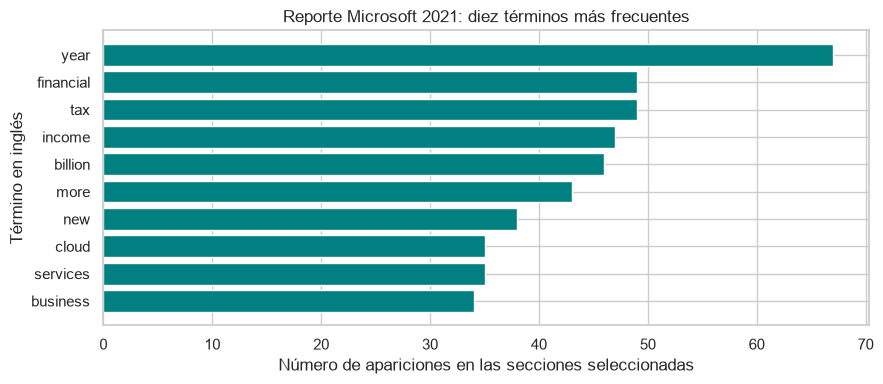

In [22]:
# La frecuencia describe menciones, no importancia económica ni sentimiento.
plt.figure(figsize=(9, 4))
plt.barh(
    frecuentes_nlp["Termino"][::-1],
    frecuentes_nlp["Frecuencia"][::-1],
    color="teal",
)
plt.title("Reporte Microsoft 2021: diez términos más frecuentes")
plt.xlabel("Número de apariciones en las secciones seleccionadas")
plt.ylabel("Término en inglés")
plt.tight_layout()
plt.show()


## 20. Representar el texto con SciPy

Construimos una matriz de **párrafos × términos**. Cada celda indica cuántas veces aparece una palabra en ese párrafo. Es una representación llamada bolsa de palabras: conserva conteos, pero pierde el orden de las palabras.

La mayoría de las combinaciones vale cero. `csr_matrix` de SciPy almacena principalmente los valores no nulos y sus posiciones. Así aplica al texto el concepto de matrices visto en clase.

Se compara el tamaño de sus arrays con una matriz densa hipotética del mismo tipo numérico. Esto mide almacenamiento de la matriz, **no toda la memoria del programa ni una aceleración de tiempo**.


In [23]:
import scipy
from scipy.sparse import csr_matrix
from collections import Counter

# Asigna una columna a cada término del vocabulario.
vocabulario_nlp = sorted(frecuencias_nlp.keys())
indice_terminos = {
    termino: posicion
    for posicion, termino in enumerate(vocabulario_nlp)
}

filas_nlp = []
columnas_nlp = []
conteos_nlp = []

for fila, tokens in enumerate(tokens_por_parrafo):
    for termino, cantidad in Counter(tokens).items():
        filas_nlp.append(fila)
        columnas_nlp.append(indice_terminos[termino])
        conteos_nlp.append(cantidad)

# Guarda únicamente las combinaciones párrafo-término presentes.
matriz_texto = csr_matrix(
    (conteos_nlp, (filas_nlp, columnas_nlp)),
    shape=(len(parrafos_nlp), len(vocabulario_nlp)),
    dtype=np.float64,
)

bytes_dispersa = (
    matriz_texto.data.nbytes
    + matriz_texto.indices.nbytes
    + matriz_texto.indptr.nbytes
)
bytes_densa = (
    matriz_texto.shape[0]
    * matriz_texto.shape[1]
    * matriz_texto.dtype.itemsize
)

# Comprueba que la matriz conserve el total contado por NLTK.
assert int(matriz_texto.sum()) == len(tokens_totales)

print("Versión de SciPy:", scipy.__version__)
print("Dimensiones (párrafos, términos):", matriz_texto.shape)
print("Combinaciones con contenido:", matriz_texto.nnz)
print("Arrays dispersos (KiB):", round(bytes_dispersa / 1024, 2))
print("Matriz densa hipotética (KiB):", round(bytes_densa / 1024, 2))
print("Reducción de almacenamiento:", f"{1 - bytes_dispersa / bytes_densa:.2%}")


Versión de SciPy: 1.18.1
Dimensiones (párrafos, términos): (139, 1776)
Combinaciones con contenido: 4713
Arrays dispersos (KiB): 55.78
Matriz densa hipotética (KiB): 1928.62
Reducción de almacenamiento: 97.11%


## 21. Localizar párrafos por tema

**Necesidad:** el analista quiere encontrar dónde se habla de un tema, por ejemplo, ingresos y crecimiento de la nube.

La consulta se procesa igual que el reporte. SciPy multiplica la matriz por el vector de la consulta. Se divide por las longitudes de ambos vectores para obtener **similitud coseno**: compara la dirección de sus conteos y reduce el efecto de la longitud del párrafo.

No es una probabilidad de relevancia ni búsqueda semántica. Solo reconoce las palabras presentes, no sinónimos o significados. Los términos muy frecuentes pueden dominar el resultado; TF-IDF sería una mejora posterior.

La salida incluye ID y enlace de sección para que el analista contraste el texto original. El código conserva los párrafos en `parrafos_nlp`, pero no reproduce todo el reporte en las salidas guardadas.


In [24]:
# Cambia esta consulta para explorar otro tema del reporte (en inglés).
consulta_nlp = "cloud revenue growth"
tokens_consulta = preparar_tokens(consulta_nlp)

# Mantiene solamente términos que existen en el corpus.
conteos_consulta = Counter(
    token for token in tokens_consulta if token in indice_terminos
)
if not conteos_consulta:
    raise ValueError("La consulta no contiene palabras del reporte. Prueba otros términos.")

vector_consulta = csr_matrix(
    (
        list(conteos_consulta.values()),
        (
            [0] * len(conteos_consulta),
            [indice_terminos[token] for token in conteos_consulta],
        ),
    ),
    shape=(1, len(vocabulario_nlp)),
    dtype=np.float64,
)

# Calcula productos punto y longitudes sin convertir toda la matriz a densa.
productos = (matriz_texto @ vector_consulta.T).toarray().ravel()
normas_parrafos = np.sqrt(matriz_texto.multiply(matriz_texto).sum(axis=1)).A1
norma_consulta = np.sqrt(vector_consulta.multiply(vector_consulta).sum())
denominadores = normas_parrafos * norma_consulta

similitudes_nlp = np.divide(
    productos,
    denominadores,
    out=np.zeros_like(productos),
    where=denominadores > 0,
)

# Muestra las mejores coincidencias, excluyendo párrafos sin términos comunes.
resultados_busqueda = parrafos_nlp[["ID", "Seccion", "Fuente"]].copy()
resultados_busqueda["Similitud"] = similitudes_nlp
resultados_busqueda = (
    resultados_busqueda.loc[resultados_busqueda["Similitud"] > 0]
    .sort_values("Similitud", ascending=False)
    .head(5)
)

print("Consulta:", consulta_nlp)
print(resultados_busqueda.round(3).to_string(index=False))
print("Revisa las secciones enlazadas para confirmar la relevancia de cada coincidencia.")


Consulta: cloud revenue growth
  ID                 Seccion                                                               Fuente  Similitud
P080 Discusión de resultados https://www.microsoft.com/investor/reports/ar21/#discussion-analysis      0.430
P106 Discusión de resultados https://www.microsoft.com/investor/reports/ar21/#discussion-analysis      0.371
P081 Discusión de resultados https://www.microsoft.com/investor/reports/ar21/#discussion-analysis      0.369
P116 Discusión de resultados https://www.microsoft.com/investor/reports/ar21/#discussion-analysis      0.296
P068 Discusión de resultados https://www.microsoft.com/investor/reports/ar21/#discussion-analysis      0.263
Revisa las secciones enlazadas para confirmar la relevancia de cada coincidencia.


## 22. Extraer cifras explícitas del texto

La carta a accionistas contiene una descripción de ingresos y resultado operativo. Aquí se usan patrones para localizar **dos importes y sus variaciones interanuales**. Se conserva el ID del párrafo para auditar el hallazgo.

Los importes de ese párrafo están redondeados en **miles de millones de USD** (`billion` en inglés). No se confunden con el precio de la acción, ni el resultado operativo con la utilidad neta. No se toman estas cifras como datos contables de precisión completa.

Esta extracción usa reglas específicas del texto en inglés: no es un modelo general que entienda cualquier reporte. Si cambia la redacción, se detiene para revisar los patrones. La búsqueda se realiza sobre el texto original, porque los tokens del bloque anterior excluyen cifras.


In [25]:
# Busca únicamente dentro de la carta para evitar mezclar cifras de otras secciones.
carta_nlp = parrafos_nlp.loc[
    parrafos_nlp["Seccion"] == "Carta a accionistas"
]

# Cada regla captura números, pero conserva por separado su significado y unidad.
reglas_cifras = {
    "Ingresos": (
        r"delivered\s+\$([\d.]+)\s+billion\s+in\s+revenue,\s+up\s+([\d.]+)\s+percent",
        1, 2,
    ),
    "Resultado operativo": (
        r"Operating income grew\s+([\d.]+)\s+percent\s+to\s+\$([\d.]+)\s+billion",
        2, 1,
    ),
}

cifras_extraidas = []

for indicador, (patron, grupo_importe, grupo_variacion) in reglas_cifras.items():
    coincidencias = []

    for _, fila in carta_nlp.iterrows():
        for coincidencia in re.finditer(patron, fila["Texto"], flags=re.IGNORECASE):
            coincidencias.append({
                "Indicador": indicador,
                "Ejercicio fiscal": 2021,
                "Importe": float(coincidencia.group(grupo_importe)),
                "Unidad": "Miles de millones USD",
                "Aumento interanual (%)": float(coincidencia.group(grupo_variacion)),
                "Parrafo": fila["ID"],
                "Fuente": fila["Fuente"],
            })

    if len(coincidencias) != 1:
        raise ValueError(f"Se esperaba una coincidencia para {indicador}; revisar la fuente.")

    cifras_extraidas.extend(coincidencias)

cifras_nlp = pd.DataFrame(cifras_extraidas)
print(cifras_nlp.to_string(index=False))
print("Importes redondeados de la carta; corroborar las tablas para precisión contable.")


          Indicador  Ejercicio fiscal  Importe                Unidad  Aumento interanual (%) Parrafo                                                              Fuente
           Ingresos              2021    168.0 Miles de millones USD                    18.0    P003 https://www.microsoft.com/investor/reports/ar21/#shareholder-letter
Resultado operativo              2021     70.0 Miles de millones USD                    32.0    P003 https://www.microsoft.com/investor/reports/ar21/#shareholder-letter
Importes redondeados de la carta; corroborar las tablas para precisión contable.


## 23. Conclusiones y límites del bloque NLP

**Qué obtiene el analista:** un índice de párrafos consultable, un conteo de términos y una tabla de dos indicadores extraídos con sus fuentes. Se reduce la necesidad de buscar desde cero; no se ha medido ahorro de tiempo frente a una lectura manual.

**Qué no obtiene:** una predicción bursátil, un análisis de sentimiento, una comprobación de veracidad del reporte ni una comprensión completa de la situación financiera. La frecuencia de una palabra tampoco mide la gravedad de un riesgo.

**Validación realizada:** se comprobó la existencia de las secciones, la conservación del conteo al construir la matriz y la coincidencia única de cada regla numérica. Esto verifica la implementación, pero no proporciona métricas de calidad NLP: para medir precisión de la búsqueda o extracción se necesitan ejemplos revisados y etiquetados por personas, y más reportes.


In [26]:
print("RESUMEN DEL ANÁLISIS DOCUMENTAL")
print(f"Se analizaron {len(parrafos_nlp)} párrafos de tres secciones del reporte 2021.")
print(f"NLTK produjo {len(tokens_totales):,} tokens filtrados y {len(vocabulario_nlp):,} términos distintos.")
print(f"SciPy representó el corpus en una matriz de {matriz_texto.shape[0]} × {matriz_texto.shape[1]}.")
print(f"La consulta devolvió {len(resultados_busqueda)} coincidencias para revisar.")
print(f"Se extrajeron {len(cifras_nlp)} indicadores con importe y variación interanual.")
print("El bloque no modifica las entradas ni las predicciones de Random Forest o PyTorch.")
print("Se implementó tokenización, no análisis de sentimiento.")


RESUMEN DEL ANÁLISIS DOCUMENTAL
Se analizaron 139 párrafos de tres secciones del reporte 2021.
NLTK produjo 5,863 tokens filtrados y 1,776 términos distintos.
SciPy representó el corpus en una matriz de 139 × 1776.
La consulta devolvió 5 coincidencias para revisar.
Se extrajeron 2 indicadores con importe y variación interanual.
El bloque no modifica las entradas ni las predicciones de Random Forest o PyTorch.
Se implementó tokenización, no análisis de sentimiento.


## 24. Evidencia de avance frente al enunciado

| Solicitud | Estado | Evidencia |
|---|---|---|
| CSV, Pandas y NumPy | Implementado | Lectura, comprobaciones, estadísticas, vectores y matrices |
| Preprocesamiento | Implementado | Limpieza, cinco indicadores derivados y escalado solo con train |
| Clasificación con Scikit-learn | Implementado | Dos Random Forest y referencia mayoritaria |
| Aprendizaje profundo | Implementado a nivel inicial | PyTorch, tensores, Autograd, Adam y validación |
| Evaluación | Implementado | División cronológica, métricas y matrices de confusión |
| Visualización | Implementado | Evolución, distribución, media móvil y comparaciones |
| NLP con SciPy y NLTK | Implementado a nivel exploratorio | Reporte oficial, tokenización, matriz dispersa, búsqueda y extracción |
| TensorFlow/Keras y red temporal | Pendiente | Solo sería necesario si el profesor exige literalmente ese framework o una red secuencial |
| Informe técnico final | Pendiente | Redactar problema, método, resultados, utilidad y limitaciones |

**Conclusión de negocio:** la solución ya automatiza revisión, transformación, visualización, comparación de modelos y consulta documental. La señal predictiva solo debe considerarse útil para inversión si supera referencias de forma estable y después demuestra valor en una simulación económica independiente.

**Siguiente mejora controlada:** evaluar más períodos temporales o un horizonte de cinco sesiones. No se recomienda modificar simultáneamente datos, objetivo, modelo y métrica, porque impediría identificar qué cambio produjo el resultado.

## Referencias
- Dataset: https://www.kaggle.com/datasets/varpit94/microsoft-stock-data
- Microsoft, reporte anual 2021: https://www.microsoft.com/investor/reports/ar21/
- PyTorch, fundamentos: https://docs.pytorch.org/tutorials/beginner/basics/intro.html
- Scikit-learn, StandardScaler: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- SciPy, matriz CSR: https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_matrix.html
- NLTK, tokenizador: https://www.nltk.org/api/nltk.tokenize.regexp.html
